# Zomato Data Analysis (EDA)

## Objective:
To analyze restaurant data and extract insights about ratings, cost, cuisines, and customer behavior.

Dataset link - from kaggle
https://www.kaggle.com/datasets/mathurutkarsh/zomato-dataset?select=zomato.csv

#### Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("zomato.csv", encoding="latin-1")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


#### Basic Exploration

In [2]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(9551, 21)
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude    

Dataset contains information about restaurants including ratings, cost, and location.

#### Data Cleaning

In [3]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [4]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

Handled missing values

In [5]:
df.duplicated().sum()    

np.int64(0)

It means: There are 0 duplicate rows in our dataset

# Analysis Section (IMPORTANT)

## Divide into sections like this:

## City Analysis

In [6]:
df["City"].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64

### Observation: 
Some cities have significantly more restaurants.
### Insight: 
High population cities have higher demand.

## ANALYSIS + VISUALIZATION
#### 1. City-wise Restaurant Count

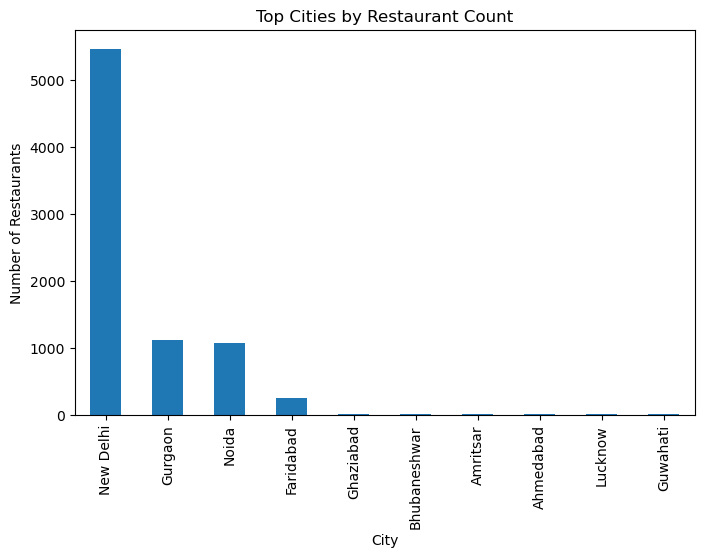

In [7]:
city_counts = df["City"].value_counts().head(10)

plt.figure(figsize=(8,5))
city_counts.plot(kind="bar")
plt.title("Top Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

#### 📌 Observation:

Top cities have significantly more restaurants

#### 💡 Insight:

Urban areas have higher food demand

#### 🏁 Conclusion:

Restaurant businesses are concentrated in major cities

## 2. Rating Distribution

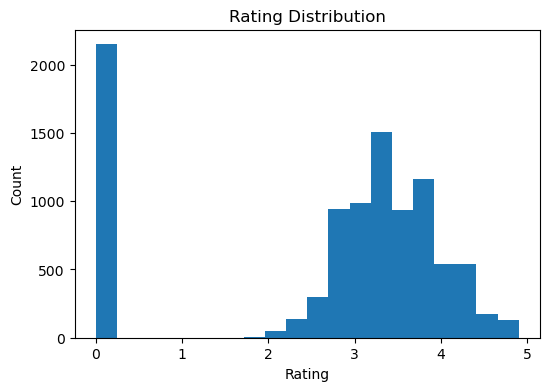

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df["Aggregate rating"], bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#### 📌 Observation:

Most ratings fall between 3.0–4.5

#### 💡 Insight:

Average quality restaurants dominate

#### 🏁 Conclusion:

Extreme ratings are rare

## 3. Cost vs Rating

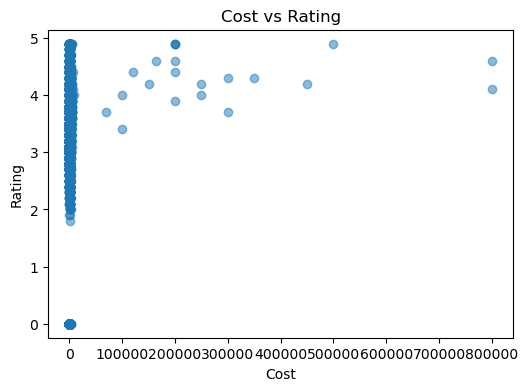

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["Average Cost for two"], df["Aggregate rating"], alpha=0.5)
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.title("Cost vs Rating")
plt.show()

### 📌 Observation:

Most low-cost restaurants have ratings between 3 and 4.5.

### 💡 Insight:

Affordable restaurants are capable of achieving high ratings similar to expensive ones.

### 🏁 Conclusion:

High ratings are not limited to expensive restaurants; cost does not strongly determine rating.

## 4. Votes vs Rating

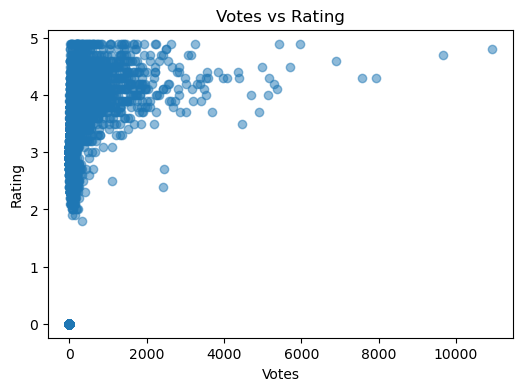

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df["Votes"], df["Aggregate rating"], alpha=0.5)
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()

### 📌 Observation:

Ratings are spread across all vote levels, with most restaurants having low votes.

### 💡 Insight:

High ratings are not limited to popular restaurants; many low-vote restaurants also have good ratings.

### 🏁 Conclusion:

There is no strong relationship between votes and ratings.

## 5. Online Delivery Impact

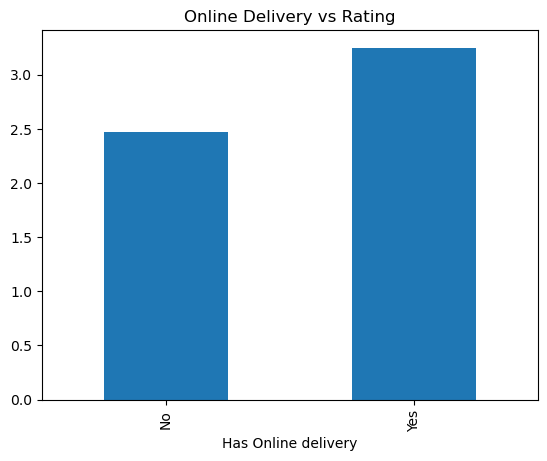

In [11]:
delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()

delivery_rating.plot(kind="bar")
plt.title("Online Delivery vs Rating")
plt.show()

#### 📌 Observation:

Online delivery restaurants have similar/slightly higher ratings

#### 💡 Insight:

Convenience affects customer satisfaction

#### 🏁 Conclusion:

Delivery plays a role in engagement

## 6. Top Cuisines

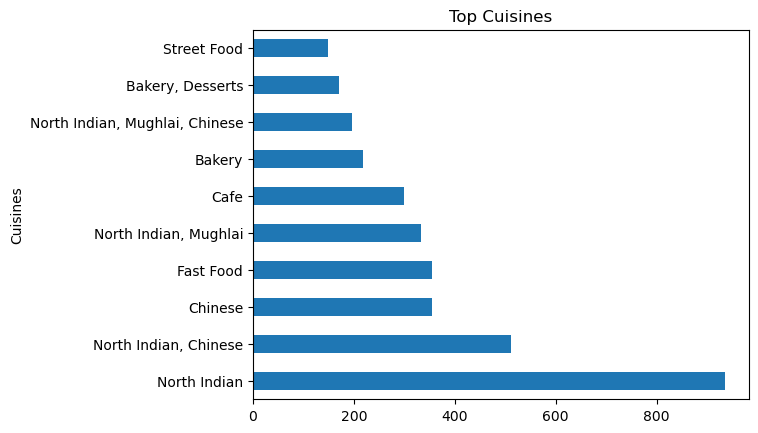

In [12]:
df["Cuisines"].value_counts().head(10).plot(kind="barh")
plt.title("Top Cuisines")
plt.show()

#### 📌 Observation:

Few cuisines dominate

#### 💡 Insight:

Customer preferences are concentrated

#### 🏁 Conclusion:

Certain cuisines drive demand

## 7. CORRELATION HEATMAP

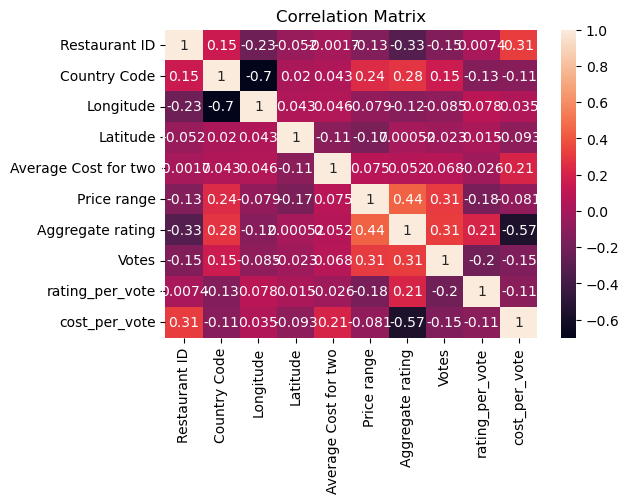

In [17]:
# Just for Practice
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

## FEATURE ENGINEERING

In [14]:
df["rating_per_vote"] = df["Aggregate rating"] / (df["Votes"] + 1)
# ⭐ Rating Efficiency
top_quality = df.sort_values("rating_per_vote", ascending=False).head(10)
top_quality[["Restaurant Name", "rating_per_vote"]]
# 👉 Finds underrated good restaurants

,Restaurant Name,rating_per_vote
53,D.O.C Ristorante,0.666667
68,Red Steak & Burger,0.650000
6124,Chaayos,0.640000
4918,Fast Trax,0.640000
1971,Curry Haus,0.620000
7640,Natkhat Bakers,0.620000
4326,Chao Cart,0.620000
7634,Gayatri's Break Point Restaurant,0.620000
2838,Anmol Chicken,0.620000
4820,Aryan's Rajasthani Pyaz Ki Kachori,0.620000


In [15]:
df["cost_per_vote"] = df["Average Cost for two"] / (df["Votes"] + 1)
# 💰 Cost Efficiency
best_value = df.sort_values("cost_per_vote").head(10)
best_value[["Restaurant Name", "cost_per_vote"]]
# 👉 Finds value-for-money restaurants

,Restaurant Name,cost_per_vote
2364,Atmosphere Grill Cafe Sheesha,0.0
201,Deorio's,0.0
639,Chapter 1 Cafe,0.0
637,Sheroes Hangout,0.0
634,The Latitude - Radisson Blu,0.0
407,Senor Iguanas,0.0
397,Royal Hotel,0.0
2368,UrbanCrave,0.0
677,The BrewMaster,0.0
240,Azteca,0.0


In [16]:
# Cost Category
df["cost_category"] = pd.cut(df["Average Cost for two"],
                            bins=[0, 500, 1500, 5000],
                            labels=["Low", "Medium", "High"])

## Final Conclusion

- Restaurant distribution is highly concentrated in major cities  
- Ratings are mostly moderate, with few extremes  
- Higher cost restaurants tend to have slightly better ratings  
- Votes and ratings show a weak positive relationship  
- Online delivery contributes to customer engagement  
- Certain cuisines dominate the market  

Overall, restaurant success depends on multiple factors including cost, location, and service quality.